# 04. Evaluation

В данном ноутбуке проводится финальная оценка моделей,
гиперпараметры которых были определены на предыдущем этапе.

На этапе оценки параметры моделей и порог классификации
не изменяются.

Финальные конфигурации:

- Logistic Regression:
  - C = 0.1
  - class_weight = balanced
  - threshold = 0.5

- Decision Tree:
  - max_depth = 8
  - min_samples_leaf = 20
  - threshold = 0.3

- Random Forest:
  - n_estimators = 500
  - max_depth = 10
  - min_samples_leaf = 10
  - threshold = 0.3

## 1. Импорт библиотек

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split

## 2. Подготовка данных

In [4]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.shape

(7043, 21)

In [5]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.loc[
    df["TotalCharges"].isna() & (df["tenure"] == 0),
    "TotalCharges"
] = 0

In [6]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [7]:
df["TotalCharges"].dtype

dtype('float64')

In [8]:
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

X = df.drop(
    columns=["Churn", "customerID"]
)

In [9]:
X.shape, y.shape

((7043, 19), (7043,))

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7040\1134790856.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


## 3. Финальные конфигурации

In [12]:
final_models = {
    "Logistic Regression": {
        "model": LogisticRegression(
            C=0.1,
            class_weight="balanced",
            max_iter=1000
        ),
        "threshold": 0.5
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            random_state=42
        ),
        "threshold": 0.3
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            min_samples_leaf=10,
            random_state=42
        ),
        "threshold": 0.3
    }
}

## 4. Обучение финальных моделей.

In [13]:
fitted_models = {}
final_predictions = {}
final_probabilities = {}

for name, config in final_models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", config["model"])
        ]
    )

    pipeline.fit(X_train, y_train)

    y_proba = pipeline.predict_proba(X_test)[:, 1]

    y_pred = (
        y_proba >= config["threshold"]
    ).astype(int)

    fitted_models[name] = pipeline
    final_probabilities[name] = y_proba
    final_predictions[name] = y_pred

In [14]:
evaluation_results = []

for name in final_models:

    y_pred = final_predictions[name]
    y_proba = final_probabilities[name]
    threshold = final_models[name]["threshold"]

    evaluation_results.append({
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

evaluation_results = pd.DataFrame(evaluation_results)

evaluation_results

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.5,0.742370,0.509565,0.783422,0.617492,0.841391
1,Decision Tree,0.3,0.750887,0.521989,0.729947,0.608696,0.819662
2,Random Forest,0.3,0.759404,0.531993,0.778075,0.631922,0.845200


## 5. Confusion Matrix

Confusion Matrix позволяет определить количество правильных и ошибочных
предсказаний каждого класса.

Матрица содержит четыре значения:

- TN — истинно отрицательные предсказания;
- FP — ложноположительные предсказания;
- FN — ложноотрицательные предсказания;
- TP — истинно положительные предсказания.

В задаче прогнозирования оттока особенно важно оценивать FN, поскольку
это клиенты, которые фактически ушли, но были классифицированы моделью
как не склонные к уходу.

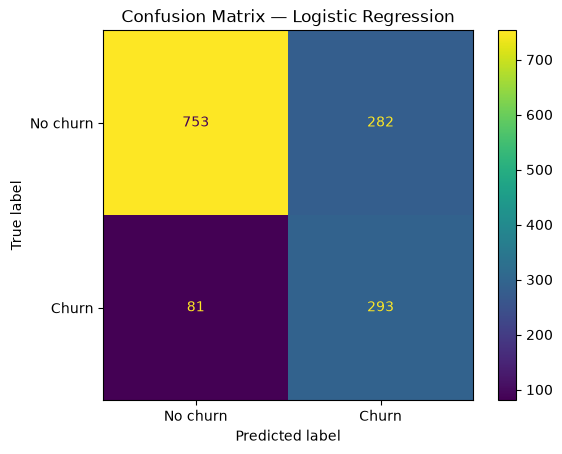

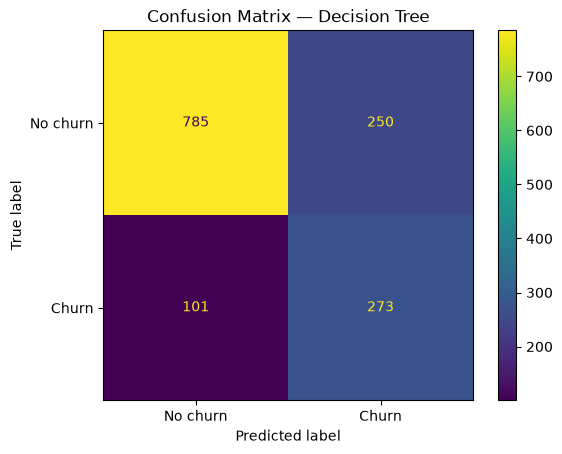

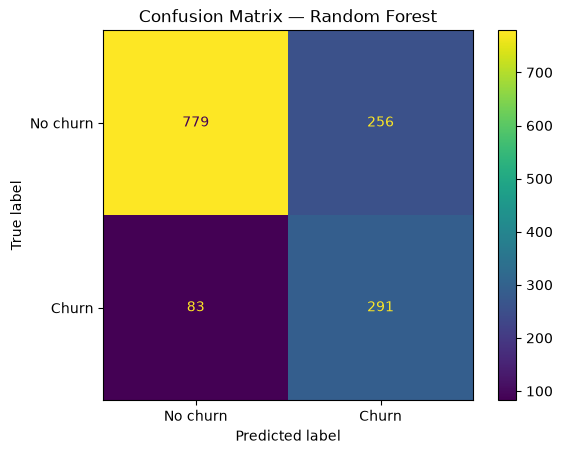

In [15]:
for name in final_models:
    cm = confusion_matrix(
        y_test,
        final_predictions[name]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No churn", "Churn"]
    )

    disp.plot()

    plt.title(f"Confusion Matrix — {name}")
    plt.show()


## 6. ROC-AUC

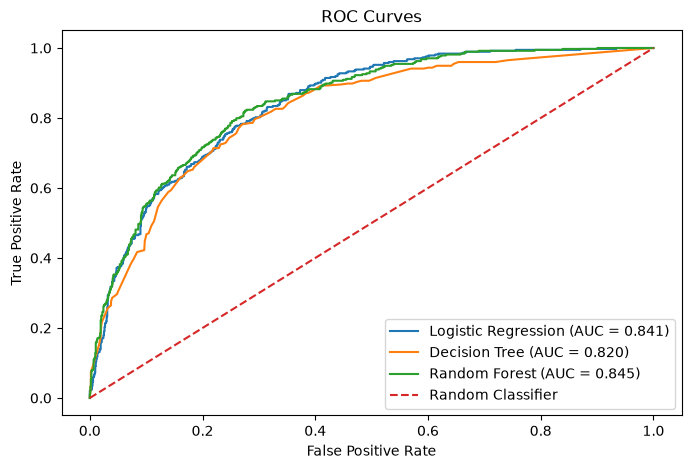

In [20]:
plt.figure(figsize=(8,5))

for name in final_models:

    y_proba = final_probabilities[name]

    fpr, tpr, _ = roc_curve(
        y_test, 
        y_proba
    )

    auc = roc_auc_score(
        y_test,
        y_proba
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle = "--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

## 7. Precision-Recall Curve

Precision-Recall Curve показывает зависимость между Precision и Recall
при изменении порога классификации.

При снижении threshold модель чаще относит клиентов к классу `Churn = 1`.
Это обычно приводит к увеличению Recall и снижению Precision.

График позволяет оценить этот компромисс для различных моделей.

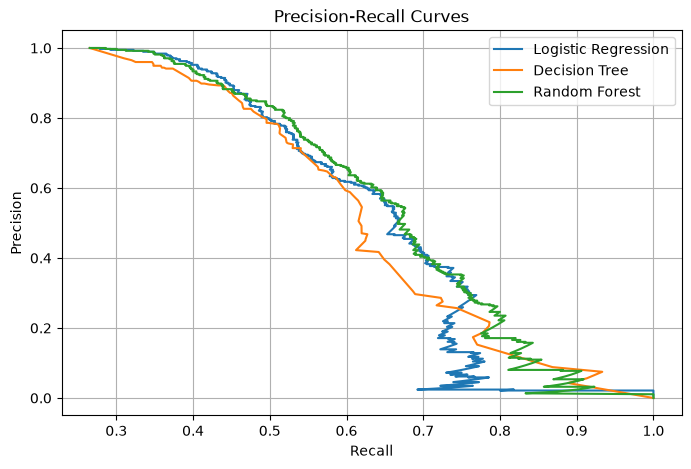

In [21]:
plt.figure(figsize=(8,5))

for name in final_models:

    y_proba = final_probabilities[name]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_proba
    )

    plt.plot(
        precision,
        recall,
        label=name
    )
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(True)
plt.show()

## 8. Распределение вероятностей предсказания

Для дополнительного анализа рассмотрим распределение вероятностей,
которые финальные модели присваивают клиентам.

Распределения рассматриваются отдельно для клиентов, которые фактически
остались (`Churn = 0`), и клиентов, которые фактически ушли
(`Churn = 1`).

Порог классификации разделяет клиентов на два класса.

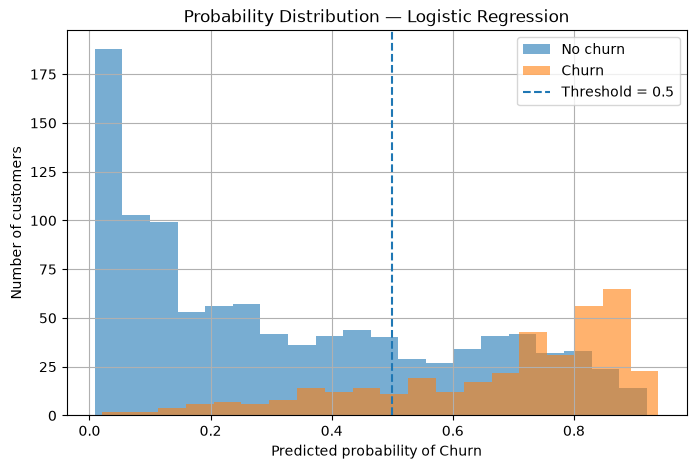

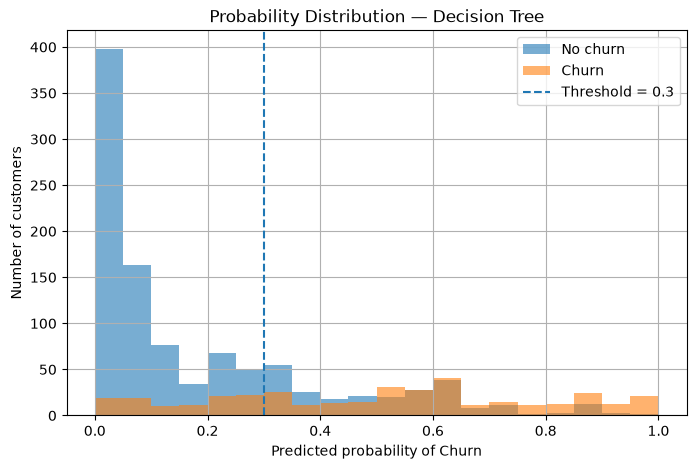

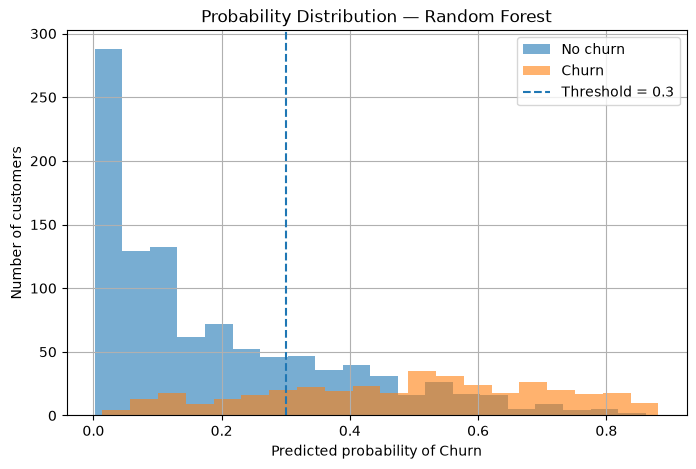

In [23]:
for name in final_models:

    y_proba = final_probabilities[name]

    plt.figure(figsize=(8,5))

    plt.hist(
        y_proba[y_test.values == 0],
        bins=20,
        alpha=0.6,
        label="No churn"
    )

    plt.hist(
        y_proba[y_test.values == 1],
        bins=20,
        alpha=0.6,
        label="Churn"
    )
    
    threshold = final_models[name]["threshold"]

    plt.axvline(
        threshold,
        linestyle="--",
        label=f"Threshold = {threshold}"
    )

    plt.xlabel("Predicted probability of Churn")
    plt.ylabel("Number of customers")
    plt.title(f"Probability Distribution — {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 9. Анализ ошибок

После оценки моделей рассмотрим типы ошибок классификации.

Особое внимание уделяется:

- False Positive — клиент был ошибочно отнесён к классу Churn;
- False Negative — фактически ушедший клиент был пропущен моделью.

Анализ ошибок позволяет понять, какой тип ошибок наиболее характерен
для каждой модели.

In [24]:
error_results = []

for name in final_models:

    cm = confusion_matrix(
        y_test,
        final_predictions[name]
    )

    tn, fp, fn, tp = cm.ravel()

    error_results.append({
        "Model": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })
error_results = pd.DataFrame(error_results)

error_results

,Model,TN,FP,FN,TP
0,Logistic Regression,753,282,81,293
1,Decision Tree,785,250,101,273
2,Random Forest,779,256,83,291


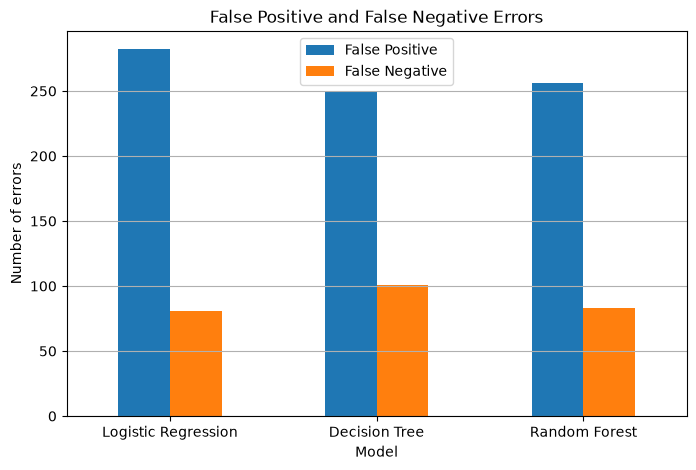

In [41]:
error_plot = error_results.set_index("Model")[
    ["FP", "FN"]
]

error_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.xlabel("Model")
plt.ylabel("Number of errors")
plt.title("False Positive and False Negative Errors")
plt.xticks(rotation=0)
plt.legend(
    ["False Positive", "False Negative"]
)
plt.grid(axis="y")
plt.show()

## 10. Выбор финальной модели

Для выбора финальной модели были сопоставлены результаты Logistic
Regression, Decision Tree и Random Forest на тестовой выборке.

Основными метриками сравнения являются F1-score и ROC-AUC, поскольку
задача характеризуется несбалансированными классами, а также важно
одновременно учитывать Precision и Recall.

Random Forest показал следующие результаты:

$$
F_1=0.632
$$

$$
ROC\text{-}AUC=0.845
$$

$$
Precision=0.532
$$

$$
Recall=0.778
$$

По совокупности рассмотренных метрик Random Forest выбирается в качестве
финальной модели проекта.

Финальная конфигурация модели:

- `n_estimators = 500`;
- `max_depth = 10`;
- `min_samples_leaf = 10`;
- `threshold = 0.3`.

Полученная модель будет использоваться в качестве итоговой модели для
предсказания оттока клиентов.

In [32]:
import joblib

final_model = fitted_models["Random Forest"]

joblib.dump(
    final_model,
    "../models/churn_random_forest.joblib"
)

['../models/churn_random_forest.joblib']